باری پروژه کارآموزی ما میخوایم فشار خون رو با استفاده از ptt بدست بیاریم که خودش از سیگنال ecg و ppg استخراج میشه

ابتدا به سراغ سایت فیزیونت رفتیم و دیتاستی را برای شروع انتخاب کردیم همانگونه که در کد زیر مشاهده میشود داده ها را استخراج کردیم که شامل سیگنال ecg و ppg بود که خارج و آن را تماشا کردیم.

try to read: D:/New folder (6)\s10_run

 read successfully
(fs): 500 Hz
signal names: ['ecg', 'pleth_1', 'pleth_2', 'pleth_3', 'pleth_4', 'pleth_5', 'pleth_6', 'lc_1', 'lc_2', 'temp_1', 'temp_2', 'temp_3', 'a_x', 'a_y', 'a_z', 'g_x', 'g_y', 'g_z']


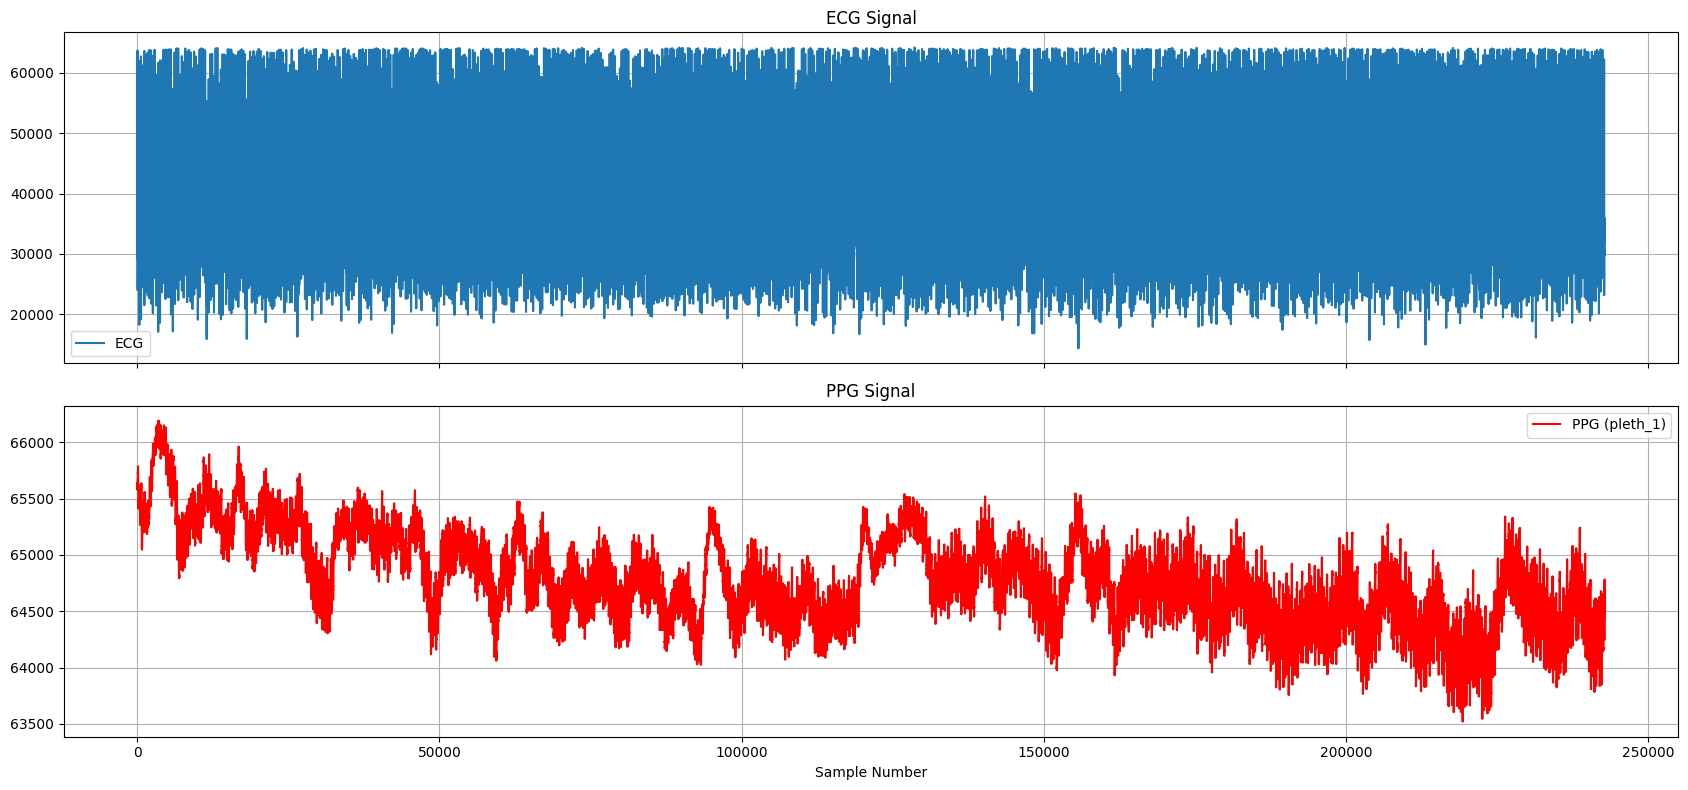

In [ ]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures 

folder_path = "D:/New folder (6)" 


base_file_name = "s10_run" 

full_path = os.path.join(folder_path, base_file_name)

print(f"try to read: {full_path}")

try:
    record = wfdb.rdrecord(full_path) 
    signals = record.p_signal
    fs = record.fs
    signal_names = record.sig_name
    print("\n read successfully")
    print(f"(fs): {fs} Hz")
    print(f"signal names: {signal_names}")

except Exception as e:
    print(f"\n error")
    print(f"why: {e}")
    print("\n do ")
    print("1. address")
    print("2. name")
    print("3. data")

import matplotlib.pyplot as plt

try:
    ecg_index = record.sig_name.index('ecg')
    ppg_index = record.sig_name.index('pleth_1')
    ecg_signal = record.p_signal[:, ecg_index]
    ppg_signal = record.p_signal[:, ppg_index]

    fig, axs = plt.subplots(2, 1, figsize=(17, 8), sharex=True)

    axs[0].plot(ecg_signal, label='ECG')
    axs[0].set_title('ECG Signal')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(ppg_signal, label='PPG (pleth_1)', color='red')
    axs[1].set_title('PPG Signal')
    axs[1].legend()
    axs[1].grid(True)

    plt.xlabel('Sample Number')
    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"one of signals does not find: {e}")

در اینجا فیلتری را رو سیگنال ها اعمال کردیم تا نویز های اضافی را حذف کنیم برای ecg فرکانس پایین 0.5 وبالای 40 وبرای ppg زیر 0.5 و بالای 4

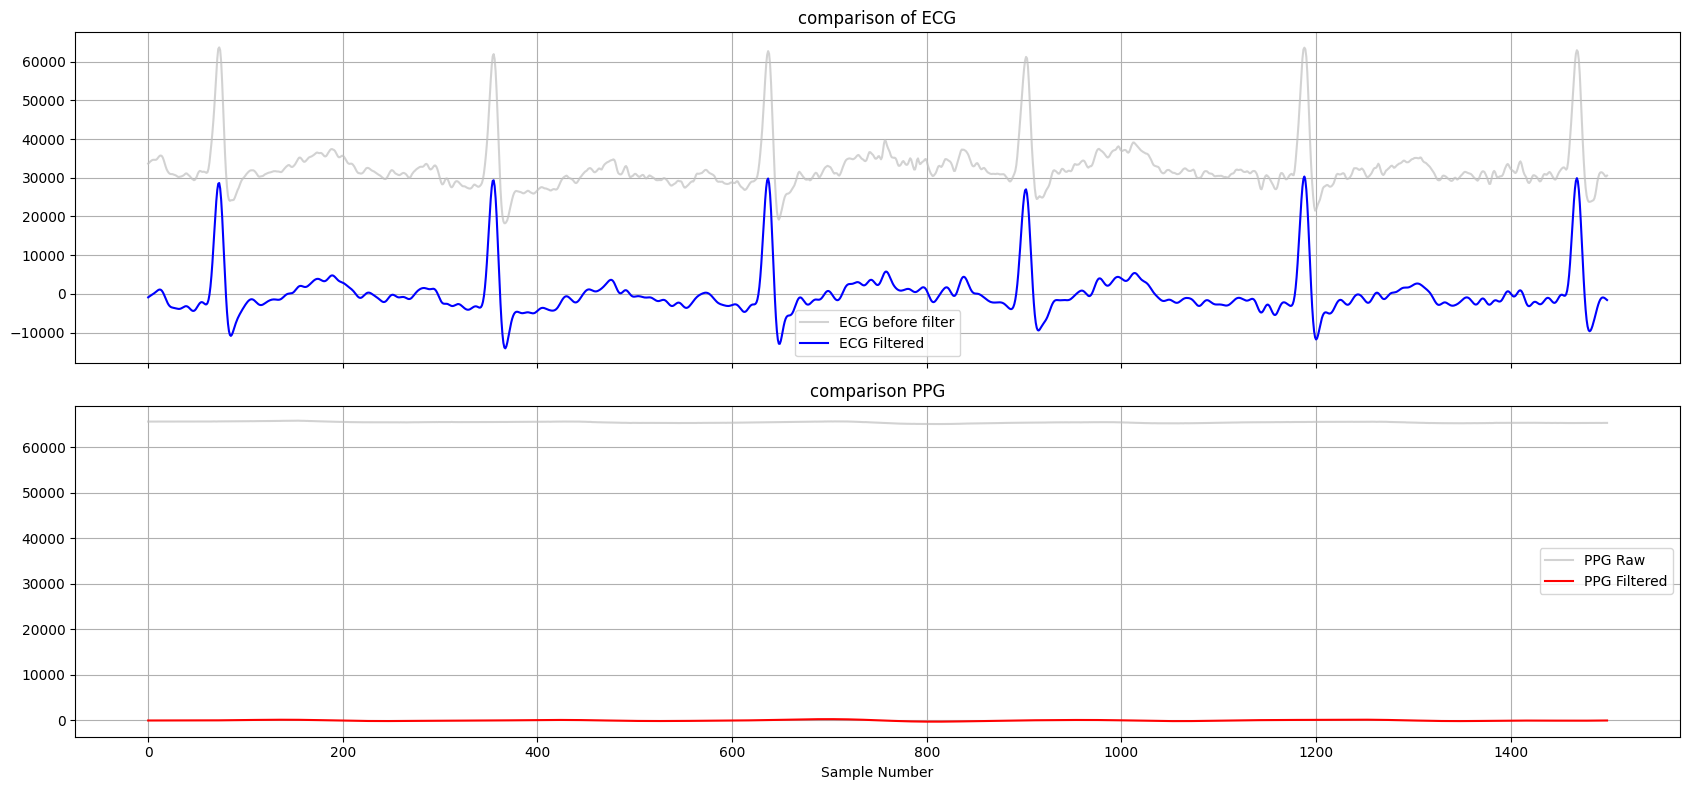

In [3]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y



fs = record.fs 
ecg_signal = record.p_signal[:, record.sig_name.index('ecg')]
ppg_signal = record.p_signal[:, record.sig_name.index('pleth_1')]
ecg_filtered = bandpass_filter(ecg_signal, lowcut=0.5, highcut=40.0, fs=fs)
ppg_filtered = bandpass_filter(ppg_signal, lowcut=0.5, highcut=4.0, fs=fs)



num_samples_to_plot = 3 * fs 

fig, axs = plt.subplots(2, 1, figsize=(17, 8), sharex=True)
axs[0].plot(ecg_signal[:num_samples_to_plot], label='ECG before filter', color='silver', alpha=0.7)
axs[0].plot(ecg_filtered[:num_samples_to_plot], label='ECG Filtered', color='blue')
axs[0].set_title('comparison of ECG')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(ppg_signal[:num_samples_to_plot], label='PPG Raw', color='silver', alpha=0.7)
axs[1].plot(ppg_filtered[:num_samples_to_plot], label='PPG Filtered', color='red')
axs[1].set_title('comparison PPG')
axs[1].legend()
axs[1].grid(True)

plt.xlabel('Sample Number')
plt.tight_layout()
plt.show()

در این بخش شروع میکنیم به یافتن پیک های هر دو سیگنال
منبع و مقاله برای روش پیدا کردن پیک (قله)
روشی که در کد شما برای پیدا کردن پیک استفاده شده، یک روش هیوریستیک (تجربی) و پرکاربرد بر اساس آستانه‌گذاری تطبیqi (Adaptive Thresholding) است. یعنی به جای یک عدد ثابت، از مشخصات آماری خود سیگنال (میانگین و انحراف معیار) برای تعیین آستانه استفاده می‌شود. این روش یک الگوریتم رسمی و نام‌گذاری شده‌ی مشخص نیست که یک مقاله مرجع داشته باشد، بلکه یک تکنیک عمومی در پردازش سیگنال است.

با این حال، اگر به دنبال یک مقاله یا روش استاندارد و معروف در این زمینه هستید، باید الگوریتم "پن-تامپکینز" (Pan-Tompkins Algorithm) را مطالعه کنید.

الگوریتم پن-تامپکینز: این الگوریتم به عنوان یکی از روش‌های کلاسیک و بسیار قابل اعتماد برای تشخیص قله‌های R (مجموعه QRS) در سیگنال ECG شناخته می‌شود. این روش بسیار دقیق‌تر از کد فعلی شما عمل می‌کند، زیرا مراحل پیچیده‌تری دارد:

فیلتر میان‌گذر (Band-pass Filter): برای حذف نویز (شبیه کاری که شما کردید).

مشتق‌گیری (Derivative): برای برجسته کردن شیب‌های تند موج QRS.

به توان دو رساندن (Squaring): برای مثبت کردن تمام مقادیر و تاکید بیشتر بر روی پیک‌ها.

انتگرال‌گیری پنجره‌ای (Moving-Window Integration): برای جمع‌آوری انرژی سیگنال در یک بازه و تولید یک موج نرم‌تر که پیدا کردن پیک در آن آسان‌تر است.

آستانه‌گذاری تطبیقی: در نهایت، این الگوریتم هم از آستانه‌های هوشمند برای تشخیص نهایی پیک‌ها استفاده می‌کند.منبع و مقاله برای روش پیدا کردن پیک (قله)
روشی که در کد شما برای پیدا کردن پیک استفاده شده، یک روش هیوریستیک (تجربی) و پرکاربرد بر اساس آستانه‌گذاری تطبیqi (Adaptive Thresholding) است. یعنی به جای یک عدد ثابت، از مشخصات آماری خود سیگنال (میانگین و انحراف معیار) برای تعیین آستانه استفاده می‌شود. این روش یک الگوریتم رسمی و نام‌گذاری شده‌ی مشخص نیست که یک مقاله مرجع داشته باشد، بلکه یک تکنیک عمومی در پردازش سیگنال است.

با این حال، اگر به دنبال یک مقاله یا روش استاندارد و معروف در این زمینه هستید، باید الگوریتم "پن-تامپکینز" (Pan-Tompkins Algorithm) را مطالعه کنید.

الگوریتم پن-تامپکینز: این الگوریتم به عنوان یکی از روش‌های کلاسیک و بسیار قابل اعتماد برای تشخیص قله‌های R (مجموعه QRS) در سیگنال ECG شناخته می‌شود. این روش بسیار دقیق‌تر از کد فعلی شما عمل می‌کند، زیرا مراحل پیچیده‌تری دارد:

فیلتر میان‌گذر (Band-pass Filter): برای حذف نویز (شبیه کاری که شما کردید).

مشتق‌گیری (Derivative): برای برجسته کردن شیب‌های تند موج QRS.

به توان دو رساندن (Squaring): برای مثبت کردن تمام مقادیر و تاکید بیشتر بر روی پیک‌ها.

انتگرال‌گیری پنجره‌ای (Moving-Window Integration): برای جمع‌آوری انرژی سیگنال در یک بازه و تولید یک موج نرم‌تر که پیدا کردن پیک در آن آسان‌تر است.

آستانه‌گذاری تطبیقی: در نهایت، این الگوریتم هم از آستانه‌های هوشمند برای تشخیص نهایی پیک‌ها استفاده می‌کند.
مقاله اصلی: Pan, J., & Tompkins, W. J. (1985). A real-time QRS detection algorithm. IEEE Transactions on Biomedical Engineering, (3), 230–236. (با جستجوی "Pan-Tompkins algorithm pdf" می‌توانید به راحتی آن را پیدا کنید).

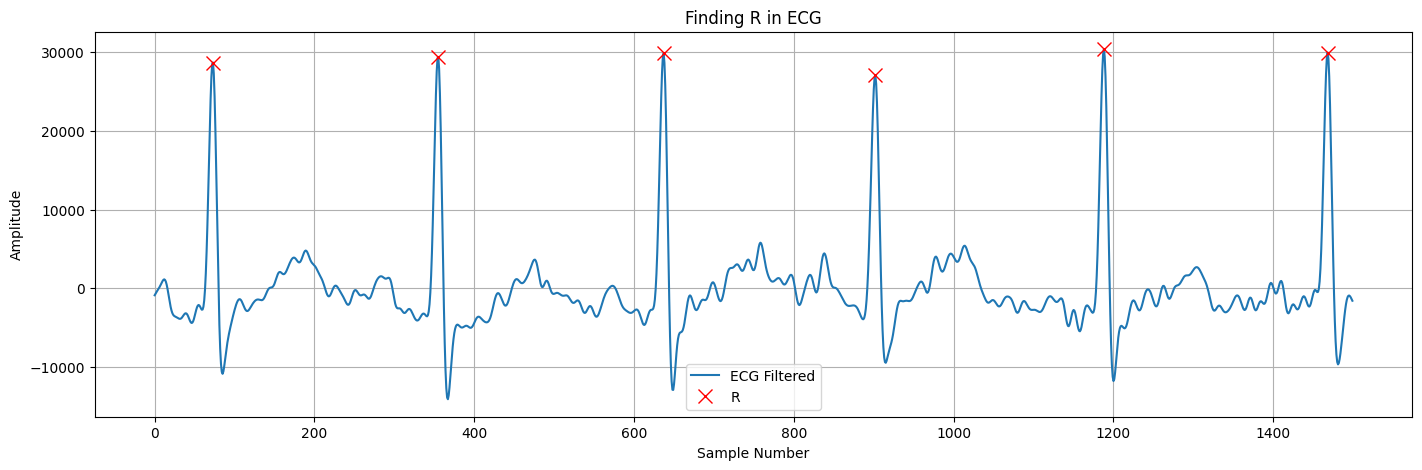


 830 Number of R found


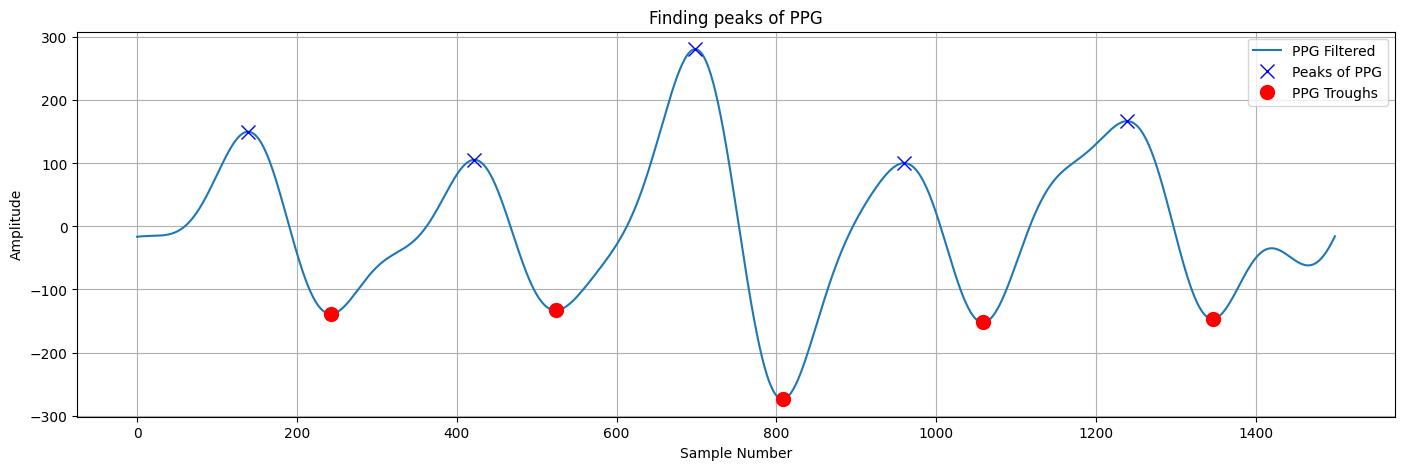


 837 


In [4]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import numpy as np

peaks, _ = find_peaks(ecg_filtered, height=np.mean(ecg_filtered) + 0.5 * np.std(ecg_filtered), distance=150)

num_samples_to_plot = 3 * fs

peaks_in_plot = peaks[peaks < num_samples_to_plot]

plt.figure(figsize=(17, 5))
plt.plot(ecg_filtered[:num_samples_to_plot], label='ECG Filtered')
plt.plot(peaks_in_plot, ecg_filtered[peaks_in_plot], "x", color='red', markersize=10, label='R')
plt.title('Finding R in ECG')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print(f"\n {len(peaks)} Number of R found")

ppg_peaks, _ = find_peaks(ppg_filtered, height=np.mean(ppg_filtered), distance=150)
ppg_troughs, _ = find_peaks(-ppg_filtered, height=-np.mean(ppg_filtered), distance=150)
num_samples_to_plot = 3 * fs
ppg_peaks_in_plot = ppg_peaks[ppg_peaks < num_samples_to_plot]
ppg_troughs_in_plot = ppg_troughs[ppg_troughs < num_samples_to_plot]

plt.figure(figsize=(17, 5))
plt.plot(ppg_filtered[:num_samples_to_plot], label='PPG Filtered')
plt.plot(ppg_peaks_in_plot, ppg_filtered[ppg_peaks_in_plot], "x", color='blue', markersize=10, label='Peaks of PPG')
plt.plot(ppg_troughs_in_plot, ppg_filtered[ppg_troughs_in_plot], "o", color='red', markersize=10, label='PPG Troughs')
plt.title('Finding peaks of PPG')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print(f"\n {len(ppg_troughs)} ")

در این بخش با استفاده از ecg و ppg به ptt رسیدیم
PTT چیست؟
PTT یا زمان انتقال پالس، مدت زمانیه که طول می‌کشه تا موج فشار ایجاد شده توسط ضربان قلب، از یک نقطه در سیستم شریانی (معمولاً قلب) به نقطه دیگری (مثل نوک انگشت یا مچ دست) برسه.

چرا PTT مهمه؟
PTT با سختی عروق و فشار خون رابطه معکوس داره. یعنی هرچه عروق سخت‌تر باشن (مثلاً در افراد مسن)، موج فشار سریع‌تر در اون‌ها حرکت می‌کنه و PTT کمتر میشه. همچنین، با افزایش فشار خون، دیواره عروق تحت کشش قرار می‌گیره، سفت‌تر میشه و در نتیجه PTT کاهش پیدا می‌کنه. به همین دلیل، PTT به عنوان یک جایگزین (surrogate marker) برای تخمین فشار خون مورد توجه قرار گرفته.

نحوه محاسبه PTT
برای محاسبه PTT به دو سیگنال فیزیولوژیک نیاز داریم:

سیگنال ECG (الکتروکاردیوگرام): این سیگنال فعالیت الکتریکی قلب رو اندازه‌گیری می‌کنه. نقطه شروع موج فشار، معمولاً با پیک R در سیگنال ECG مشخص میشه که نشان‌دهنده انقباض بطن‌های قلب و شروع پمپاژ خونه.

سیگنال PPG (فتوپلتیسموگرافی): این سیگنال تغییرات حجم خون در عروق محیطی (مثل انگشت) رو اندازه‌گیری می‌کنه. نقطه پایان PTT با شروع افزایش حجم خون در محل اندازه‌گیری PPG مشخص میشه. در کد شما، این نقطه با فرورفتگی (trough) در سیگنال PPG مشخص شده.

فرمول کلی برای PTT به صورت زیره:

PTT=t 
PPG
​
 −t 
ECG
​
 

t 
PPG
​
 
: زمان رسیدن پالس به محل اندازه‌گیری PPG (نقطه شروع موج PPG).

t 
ECG
​
 
: زمان شروع انقباض قلب (پیک R در ECG).

مقالات و منابع علمی 📚
برای مطالعه بیشتر در مورد PTT و کاربردهای اون، می‌تونید به مقالات و منابع زیر مراجعه کنید:

A review of methods for non-invasive blood pressure measurement: این مقاله یک بررسی جامع از روش‌های مختلف اندازه‌گیری غیرتهاجمی فشار خون، از جمله روش‌های مبتنی بر PTT، ارائه میده.

Pulse transit time as a measure of arterial stiffness and blood pressure: این مقاله به طور خاص به رابطه PTT با سختی عروق و فشار خون می‌پردازه.

Journal of Medical and Biological Engineering & Computing (Springer): این ژورنال حاوی مقالات بسیار زیادی در زمینه پردازش سیگنال‌های پزشکی و کاربردهای اون‌ها برای پایش پارامترهای فیزیولوژیک از جمله PTT هست. می‌تونید با جستجوی واژه‌های کلیدی مثل "Pulse Transit Time", "PTT-based blood pressure estimation" و "arterial stiffness" به مقالات مرتبط دسترسی پیدا کنید.

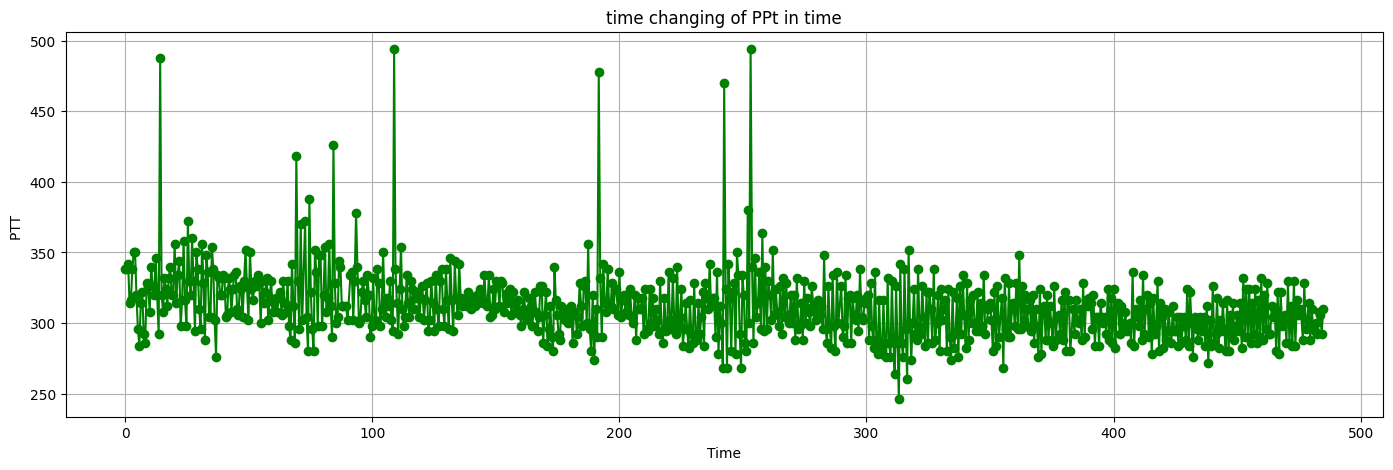


 Success
Avrage of PTT 311.53 ms


In [5]:
ptt_values_ms = [] 
ptt_peak_times = [] 

for r_peak in peaks:
   
    future_troughs_indices = np.where(ppg_troughs > r_peak)[0]
    
    if len(future_troughs_indices) > 0:
        first_future_trough_index = future_troughs_indices[0]
        corresponding_trough = ppg_troughs[first_future_trough_index]
        ptt_samples = corresponding_trough - r_peak
        ptt_ms = (ptt_samples / fs) * 1000
        
        if 50 < ptt_ms < 500:
            ptt_values_ms.append(ptt_ms)
            ptt_peak_times.append(r_peak / fs)

plt.figure(figsize=(17, 5))
plt.plot(ptt_peak_times, ptt_values_ms, marker='o', linestyle='-', color='green')
plt.title('time changing of PPt in time')
plt.xlabel('Time')
plt.ylabel('PTT ')
plt.grid(True)
plt.show()

print(f"\n Success")
print(f"Avrage of PTT {np.mean(ptt_values_ms):.2f} ms")

دیتاست قبل فشار خون نداشت و مجبور شدیم یکبار دیگر به دنبال دیتاست بگردیم و درنهای فشار خون را با ptt فشار خون مقایسه کنیم

Attempting to read record: D:/New folder (6)\3229745_0016
Record read successfully. Sampling Frequency: 125 Hz
All required signals ('II', 'PLETH', 'ABP') found in the record.


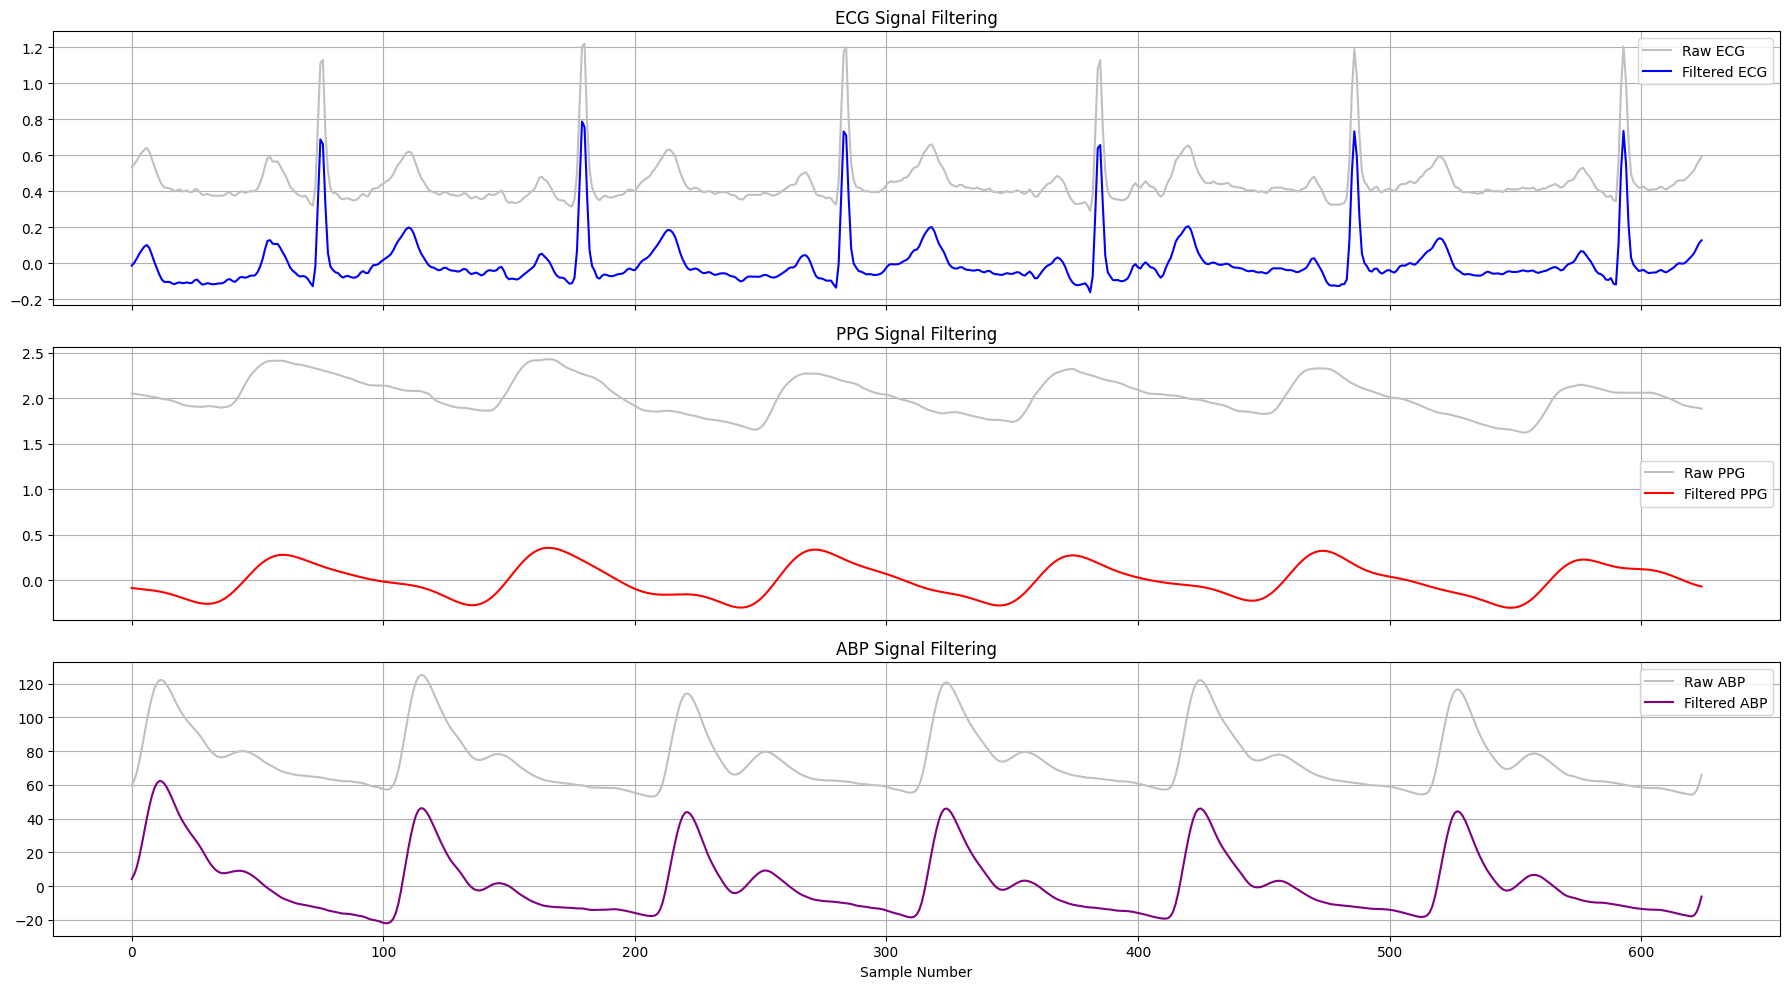

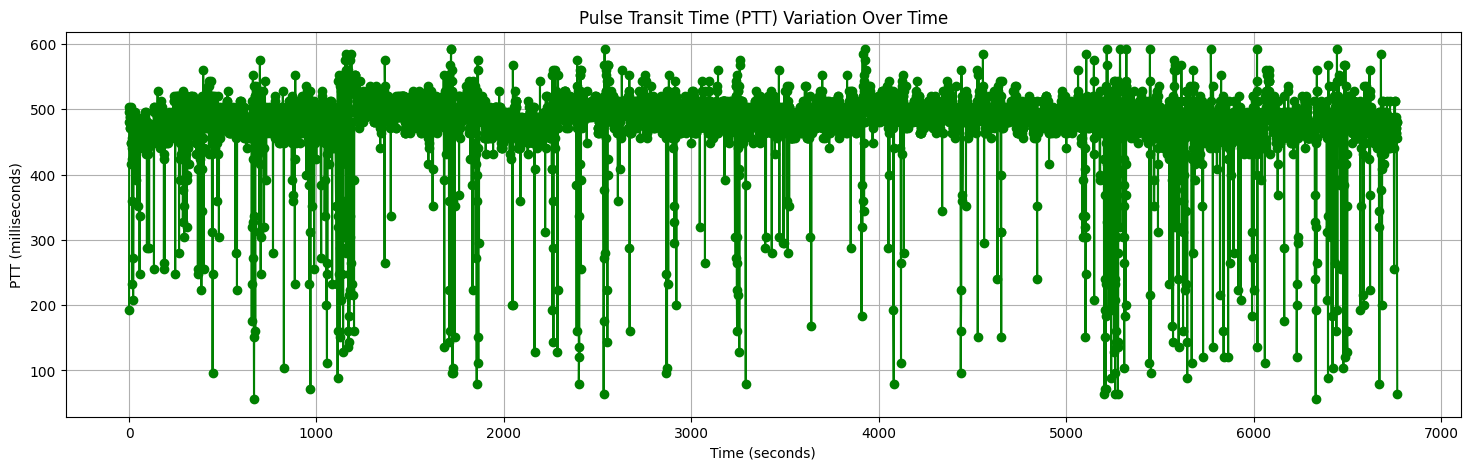

PTT calculation complete. Found 8575 valid PTT values.
Average PTT: 478.12 ms


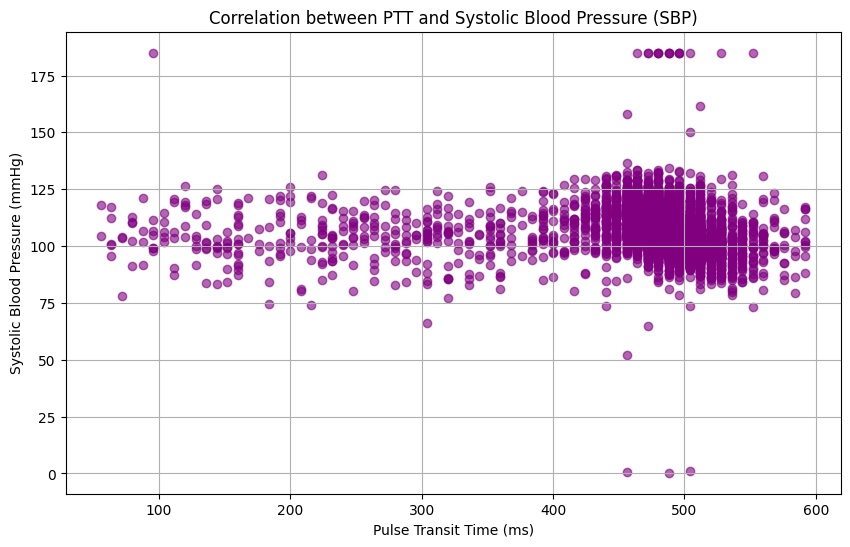


Project Complete!


In [6]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

folder_path = "D:/New folder (6)"  
base_file_name = "3229745_0016"  
full_path = os.path.join(folder_path, base_file_name)
print(f"Attempting to read record: {full_path}")

try:
    record = wfdb.rdrecord(full_path)
    fs = record.fs
    print(f"Record read successfully. Sampling Frequency: {fs} Hz")
    ecg_index = record.sig_name.index('II')
    ppg_index = record.sig_name.index('PLETH')
    abp_index = record.sig_name.index('ABP')
    print("All required signals ('II', 'PLETH', 'ABP') found in the record.")
    ecg_signal_raw = record.p_signal[:, ecg_index]
    ppg_signal_raw = record.p_signal[:, ppg_index]
    abp_signal_raw = record.p_signal[:, abp_index]

except Exception as e:
    print(f"An error occurred: {e}")
    exit()

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y
ecg_filtered = bandpass_filter(ecg_signal_raw, lowcut=0.5, highcut=40.0, fs=fs)
ppg_filtered = bandpass_filter(ppg_signal_raw, lowcut=0.5, highcut=4.0, fs=fs)
abp_filtered = bandpass_filter(abp_signal_raw, lowcut=0.5, highcut=30.0, fs=fs)

fig, axs = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
num_samples_to_plot = 5 * fs  # نمایش ۵ ثانیه

# ECG Plot
axs[0].plot(ecg_signal_raw[:num_samples_to_plot], label='Raw ECG', color='silver')
axs[0].plot(ecg_filtered[:num_samples_to_plot], label='Filtered ECG', color='blue')
axs[0].set_title('ECG Signal Filtering')
axs[0].legend()
axs[0].grid(True)

# PPG Plot
axs[1].plot(ppg_signal_raw[:num_samples_to_plot], label='Raw PPG', color='silver')
axs[1].plot(ppg_filtered[:num_samples_to_plot], label='Filtered PPG', color='red')
axs[1].set_title('PPG Signal Filtering')
axs[1].legend()
axs[1].grid(True)

# ABP Plot
axs[2].plot(abp_signal_raw[:num_samples_to_plot], label='Raw ABP', color='silver')
axs[2].plot(abp_filtered[:num_samples_to_plot], label='Filtered ABP', color='purple')
axs[2].set_title('ABP Signal Filtering')
axs[2].legend()
axs[2].grid(True)

plt.xlabel('Sample Number')
plt.tight_layout()
plt.show()


ecg_peak_distance = int(0.5 * fs) # حداقل فاصله معادل 0.5 ثانیه
ecg_peaks, _ = find_peaks(ecg_filtered, height=np.mean(ecg_filtered), distance=ecg_peak_distance)


ppg_trough_distance = int(0.5 * fs)
ppg_troughs, _ = find_peaks(-ppg_filtered, height=-np.mean(ppg_filtered), distance=ppg_trough_distance)

# --- محاسبه PTT ---
ptt_values_ms = []
ptt_peak_times_sec = []

for r_peak in ecg_peaks:
    future_troughs = ppg_troughs[ppg_troughs > r_peak]
    if len(future_troughs) > 0:
        corresponding_trough = future_troughs[0]
        ptt_samples = corresponding_trough - r_peak
        ptt_ms = (ptt_samples / fs) * 1000
        
        if 50 < ptt_ms < 600: 
            ptt_values_ms.append(ptt_ms)
            ptt_peak_times_sec.append(r_peak / fs)

plt.figure(figsize=(18, 5))
plt.plot(ptt_peak_times_sec, ptt_values_ms, marker='o', linestyle='-', color='green')
plt.title('Pulse Transit Time (PTT) Variation Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('PTT (milliseconds)')
plt.grid(True)
plt.show()

print(f"PTT calculation complete. Found {len(ptt_values_ms)} valid PTT values.")
print(f"Average PTT: {np.mean(ptt_values_ms):.2f} ms")



abp_peak_distance = int(0.5 * fs)
sbp_peaks, _ = find_peaks(abp_filtered, height=np.mean(abp_filtered), distance=abp_peak_distance)
dbp_peaks, _ = find_peaks(-abp_filtered, height=-np.mean(abp_filtered), distance=abp_peak_distance)

# استخراج مقادیر فشار خون سیستولیک 
sbp_values = abp_signal_raw[sbp_peaks]

# پیدا کردن مقدار فشار خون سیستولیک متناظر با هر PTT
correlated_sbp = []
correlated_ptt = []

for i, ptt_time in enumerate(ptt_peak_times_sec):
    time_diffs = np.abs((sbp_peaks / fs) - ptt_time)
    if np.min(time_diffs) < 0.5:
        closest_sbp_index = np.argmin(time_diffs)
        correlated_sbp.append(sbp_values[closest_sbp_index])
        correlated_ptt.append(ptt_values_ms[i])


plt.figure(figsize=(10, 6))
plt.scatter(correlated_ptt, correlated_sbp, alpha=0.6, color='purple')
plt.title('Correlation between PTT and Systolic Blood Pressure (SBP)')
plt.xlabel('Pulse Transit Time (ms)')
plt.ylabel('Systolic Blood Pressure (mmHg)')
plt.grid(True)
plt.show()

print("\nProject Complete!")

مدل رگرسیون خطی (Linear Regression Model)
هدف: در این بخش، یک مدل رگرسیون خطی ساده برای پیدا کردن رابطه ریاضی بین PTT و فشار خون سیستولیک (SBP) آموزش داده میشه.

PTT به عنوان ورودی (X): مقدار PTT (که قبلاً از سیگنال‌های ECG و PPG محاسبه شده) به عنوان ویژگی ورودی مدل (X) استفاده میشه. reshape(-1, 1) برای تغییر شکل آرایه به فرمت مورد نیاز کتابخانه scikit-learn ضروریه.

SBP به عنوان خروجی (y): مقادیر واقعی فشار خون سیستولیک (که از سیگنال ABP استخراج شده) به عنوان خروجی مورد انتظار مدل (y) استفاده میشه.

model.fit(X, y): این خط، مدل رو بر اساس داده‌های ورودی و خروجی آموزش میده. مدل یک خط مستقیم رو پیدا می‌کنه که بهترین تطابق رو با داده‌ها داره. این خط، رابطه بین PTT و SBP رو به صورت خطی مدل می‌کنه.

model.predict(X): بعد از آموزش مدل، این خط از مدل برای پیش‌بینی مقادیر SBP بر اساس همان مقادیر PTT استفاده می‌کنه. این مقادیر پیش‌بینی شده (sbp_predicted) در مرحله بعدی با مقادیر واقعی SBP مقایسه میشن.

Attempting to read record: D:/New folder (6)\3229745_0016
Record read successfully. Sampling Frequency: 125 Hz
All required signals ('II', 'PLETH', 'ABP') found in the record.

Generating final time-series comparison plot...


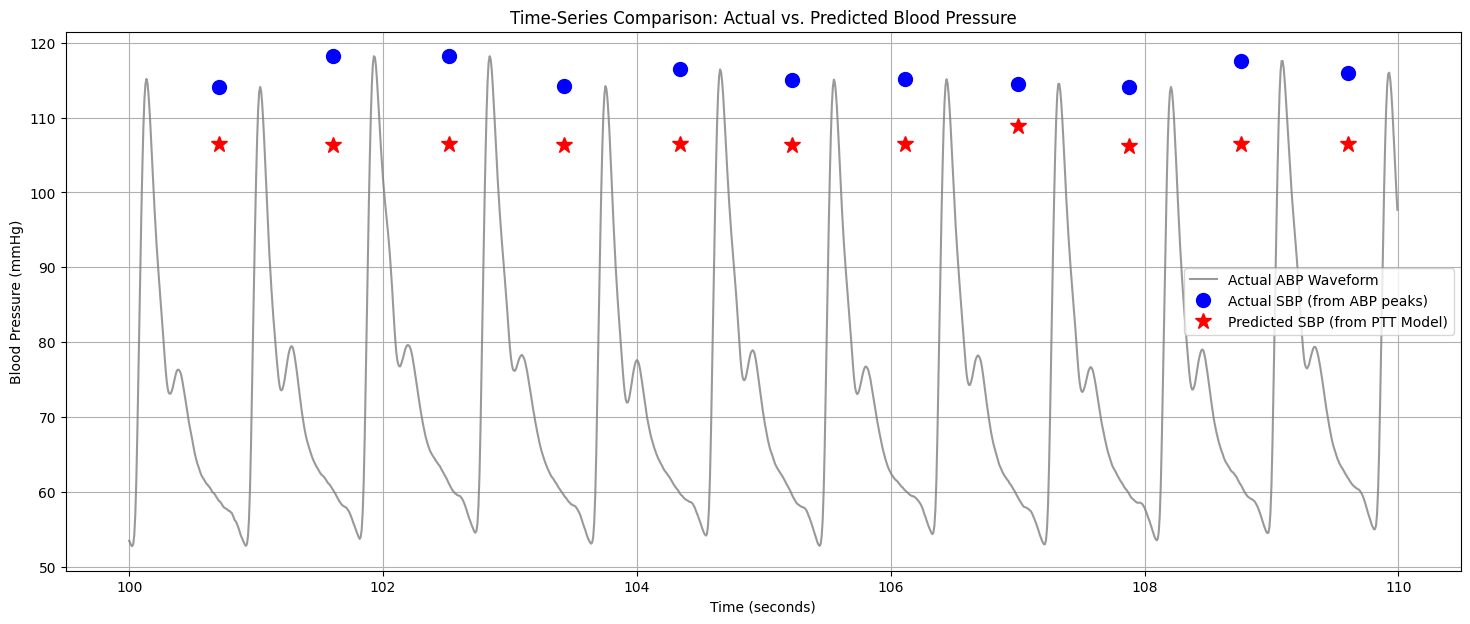

In [7]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.linear_model import LinearRegression

folder_path = "D:/New folder (6)"
base_file_name = "3229745_0016" 

full_path = os.path.join(folder_path, base_file_name)
print(f"Attempting to read record: {full_path}")

try:
    record = wfdb.rdrecord(full_path)
    fs = record.fs
    print(f"Record read successfully. Sampling Frequency: {fs} Hz")
    ecg_index = record.sig_name.index('II')
    ppg_index = record.sig_name.index('PLETH')
    abp_index = record.sig_name.index('ABP')
    print("All required signals ('II', 'PLETH', 'ABP') found in the record.")

    ecg_signal_raw = record.p_signal[:, ecg_index]
    ppg_signal_raw = record.p_signal[:, ppg_index]
    abp_signal_raw = record.p_signal[:, abp_index]
except Exception as e:
    print(f"An error occurred: {e}")
    exit()

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs; low = lowcut / nyquist; high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band'); y = filtfilt(b, a, data)
    return y

ecg_filtered = bandpass_filter(ecg_signal_raw, lowcut=0.5, highcut=40.0, fs=fs)
ppg_filtered = bandpass_filter(ppg_signal_raw, lowcut=0.5, highcut=4.0, fs=fs)

ecg_peak_distance = int(0.5 * fs)
ecg_peaks, _ = find_peaks(ecg_filtered, height=np.mean(ecg_filtered), distance=ecg_peak_distance)
ppg_trough_distance = int(0.5 * fs)
ppg_troughs, _ = find_peaks(-ppg_filtered, height=-np.mean(ppg_filtered), distance=ppg_trough_distance)

ptt_values_ms = []; ptt_peak_times_sec = []
for r_peak in ecg_peaks:
    future_troughs = ppg_troughs[ppg_troughs > r_peak]
    if len(future_troughs) > 0:
        ptt_samples = future_troughs[0] - r_peak; ptt_ms = (ptt_samples / fs) * 1000
        if 50 < ptt_ms < 600:
            ptt_values_ms.append(ptt_ms); ptt_peak_times_sec.append(r_peak / fs)
abp_filtered = bandpass_filter(abp_signal_raw, lowcut=0.5, highcut=30.0, fs=fs)
sbp_peaks, _ = find_peaks(abp_filtered, height=np.mean(abp_filtered), distance=int(0.5*fs))
sbp_values = abp_signal_raw[sbp_peaks]

correlated_sbp = []; correlated_ptt = []; correlated_ptt_times = []
for i, ptt_time in enumerate(ptt_peak_times_sec):
    time_diffs = np.abs((sbp_peaks / fs) - ptt_time)
    if np.min(time_diffs) < 0.5:
        closest_sbp_index = np.argmin(time_diffs)
        correlated_sbp.append(sbp_values[closest_sbp_index])
        correlated_ptt.append(ptt_values_ms[i])
        correlated_ptt_times.append(ptt_time)

X = np.array(correlated_ptt).reshape(-1, 1)
y = np.array(correlated_sbp)

model = LinearRegression(); model.fit(X, y)
sbp_predicted = model.predict(X)
print("\nGenerating final time-series comparison plot...")

start_time_sec = 100
end_time_sec = start_time_sec + 10

start_sample = int(start_time_sec * fs)
end_sample = int(end_time_sec * fs)
time_axis_segment = np.arange(start_sample, end_sample) / fs

plt.figure(figsize=(18, 7))
plt.plot(time_axis_segment, abp_signal_raw[start_sample:end_sample], color='gray', alpha=0.8, label='Actual ABP Waveform')

indices_in_segment = [i for i, t in enumerate(correlated_ptt_times) if start_time_sec < t < end_time_sec]

if indices_in_segment:
    times_in_segment = [correlated_ptt_times[i] for i in indices_in_segment]
    actual_sbp_in_segment = [y[i] for i in indices_in_segment]
    predicted_sbp_in_segment = [sbp_predicted[i] for i in indices_in_segment]
    plt.plot(times_in_segment, actual_sbp_in_segment, 'o', color='blue', markersize=10, label='Actual SBP (from ABP peaks)')
    plt.plot(times_in_segment, predicted_sbp_in_segment, '*', color='red', markersize=12, label='Predicted SBP (from PTT Model)')

plt.title('Time-Series Comparison: Actual vs. Predicted Blood Pressure')
plt.xlabel('Time (seconds)')
plt.ylabel('Blood Pressure (mmHg)')
plt.legend()
plt.grid(True)
plt.show()

رگرسیون چندجمله‌ای (Polynomial Regression)
هدف: این بخش یک مدل غیرخطی برای پیش‌بینی SBP بر اساس PTT ایجاد می‌کند. برخلاف رگرسیون خطی ساده که یک خط مستقیم را برازش می‌دهد، رگرسیون چندجمله‌ای یک منحنی (در اینجا از درجه ۲) را به داده‌ها برازش می‌دهد. این کار به مدل اجازه می‌دهد تا روابط پیچیده‌تر و غیرخطی بین متغیرها را بهتر یاد بگیرد.

PolynomialFeatures(degree=2): این تابع از scikit-learn ویژگی‌های چندجمله‌ای جدیدی را از ویژگی‌های موجود (X) ایجاد می‌کند. با degree=2، یک ستون جدید به داده‌ها اضافه می‌شود که حاوی مقادیر PTT^2 است. این تبدیل داده، به مدل رگرسیون خطی امکان می‌دهد تا به جای یک خط، یک منحنی درجه دو را برازش دهد.

چرا این کار مهم است؟ روابط فیزیولوژیک در بدن انسان اغلب خطی نیستند. رابطه بین PTT و فشار خون نیز از یک فرمول غیرخطی پیروی می‌کند. استفاده از رگرسیون چندجمله‌ای به مدل شما انعطاف‌پذیری بیشتری می‌دهد تا این رابطه واقعی را با دقت بهتری مدل‌سازی کند، که احتمالاً منجر به پیش‌بینی‌های دقیق‌تری می‌شود.


Building the Polynomial Prediction Model...

Generating final time-series comparison plot...


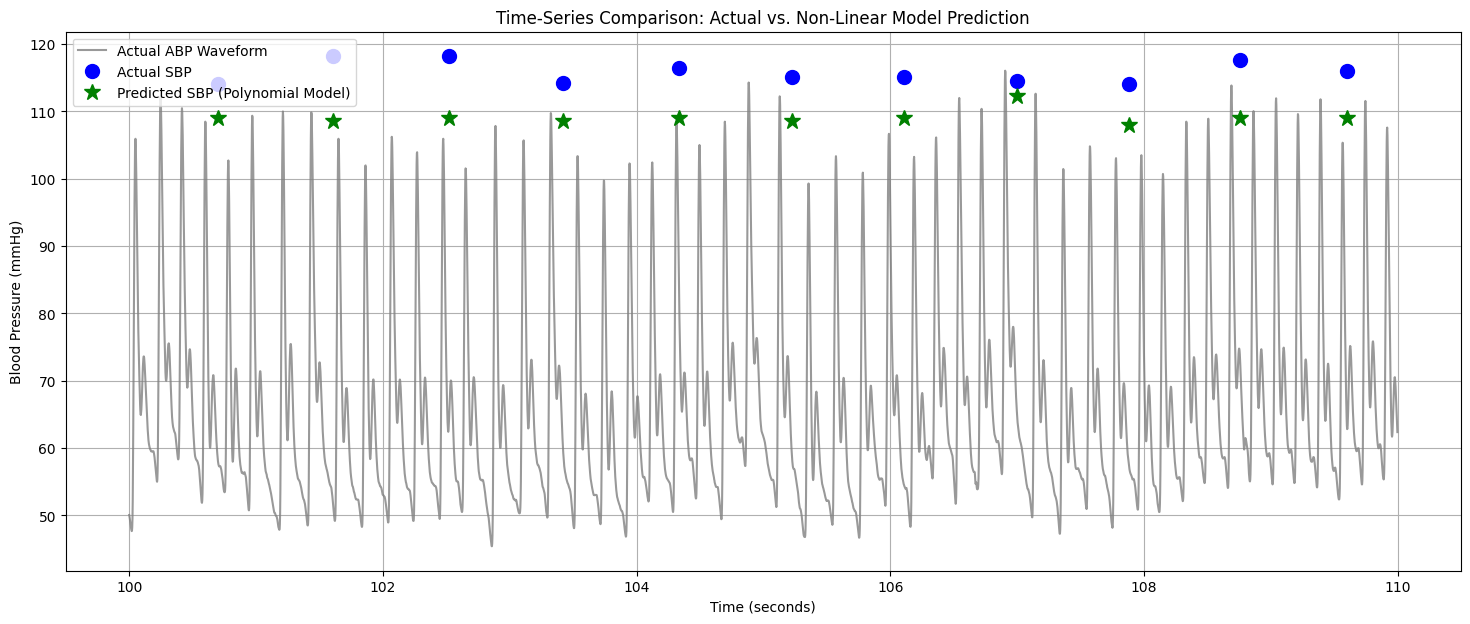

In [10]:
print("\nBuilding the Polynomial Prediction Model...")

X = np.array(correlated_ptt).reshape(-1, 1)
y = np.array(correlated_sbp)

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
sbp_predicted_poly = poly_model.predict(X_poly)

print("\nGenerating final time-series comparison plot...")

start_time_sec = 100
end_time_sec = start_time_sec + 10
start_sample = int(start_time_sec * fs)
end_sample = int(end_time_sec * fs)
time_axis_segment = np.arange(start_sample, end_sample) / fs

plt.figure(figsize=(18, 7))
plt.plot(time_axis_segment, abp_signal_raw[start_sample:end_sample], color='gray', alpha=0.8, label='Actual ABP Waveform')

indices_in_segment = [i for i, t in enumerate(correlated_ptt_times) if start_time_sec < t < end_time_sec]

if indices_in_segment:
    times_in_segment = [correlated_ptt_times[i] for i in indices_in_segment]
    actual_sbp_in_segment = [y[i] for i in indices_in_segment]
    predicted_sbp_in_segment = [sbp_predicted_poly[i] for i in indices_in_segment]
    
    plt.plot(times_in_segment, actual_sbp_in_segment, 'o', color='blue', markersize=10, label='Actual SBP')
    plt.plot(times_in_segment, predicted_sbp_in_segment, '*', color='green', markersize=12, label='Predicted SBP (Polynomial Model)')

plt.title('Time-Series Comparison: Actual vs. Non-Linear Model Prediction')
plt.xlabel('Time (seconds)')
plt.ylabel('Blood Pressure (mmHg)')
plt.legend()
plt.grid(True)
plt.show()

اینجا از رندوم فارست برای پیشبینی استفاده کردم

Attempting to read record: D:/New folder (6)\3229745_0016
Record read successfully. Sampling Frequency: 125 Hz
All required signals ('II', 'PLETH', 'ABP') found.

Building separate models for SBP and DBP...

Generating final comparison plot...


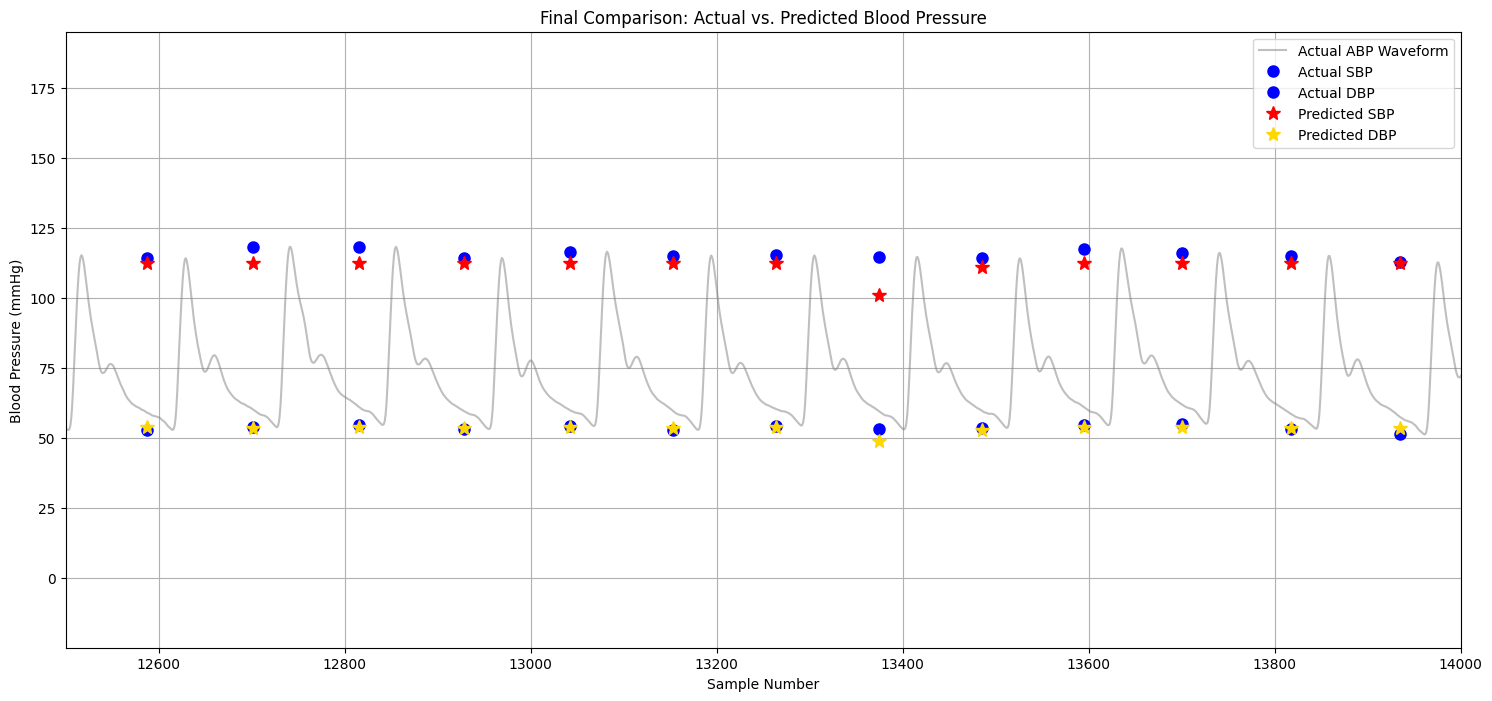

Mean Absolute Error (MAE) for SBP: 5.92 mmHg
Root Mean Squared Error (RMSE) for SBP: 8.03 mmHg
R-squared (R2) for SBP: 0.15
Mean Absolute Error (MAE) for DBP: 5.92 mmHg
Root Mean Squared Error (RMSE) for DBP: 8.03 mmHg
R-squared (R2) for DBP: 0.15


In [3]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import RandomForestRegressor

folder_path = "D:/New folder (6)"
base_file_name = "3229745_0016" 

full_path = os.path.join(folder_path, base_file_name)
print(f"Attempting to read record: {full_path}")
try:
    record = wfdb.rdrecord(full_path); fs = record.fs
    print(f"Record read successfully. Sampling Frequency: {fs} Hz")
    ecg_index = record.sig_name.index('II'); ppg_index = record.sig_name.index('PLETH'); abp_index = record.sig_name.index('ABP')
    print("All required signals ('II', 'PLETH', 'ABP') found.")
    ecg_signal_raw = record.p_signal[:, ecg_index]; ppg_signal_raw = record.p_signal[:, ppg_index]; abp_signal_raw = record.p_signal[:, abp_index]
except Exception as e:
    print(f"An error occurred: {e}"); exit()

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs; low = lowcut / nyquist; high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band'); y = filtfilt(b, a, data)
    return y
ecg_filtered = bandpass_filter(ecg_signal_raw, 0.5, 40.0, fs); ppg_filtered = bandpass_filter(ppg_signal_raw, 0.5, 4.0, fs); abp_filtered = bandpass_filter(abp_signal_raw, 0.5, 30.0, fs)

ecg_peaks, _ = find_peaks(ecg_filtered, height=np.mean(ecg_filtered), distance=int(0.5*fs))
ppg_troughs, _ = find_peaks(-ppg_filtered, height=-np.mean(ppg_filtered), distance=int(0.5*fs))
ptt_values_ms = []; ptt_peak_times_sec = []
for r_peak in ecg_peaks:
    future_troughs = ppg_troughs[ppg_troughs > r_peak]
    if len(future_troughs) > 0:
        ptt_samples = future_troughs[0] - r_peak; ptt_ms = (ptt_samples / fs) * 1000
        if 50 < ptt_ms < 600:
            ptt_values_ms.append(ptt_ms); ptt_peak_times_sec.append(r_peak / fs)

abp_peak_distance = int(0.5 * fs)
sbp_peaks, _ = find_peaks(abp_filtered, height=np.mean(abp_filtered), distance=abp_peak_distance)
sbp_values = abp_signal_raw[sbp_peaks]
dbp_peaks, _ = find_peaks(-abp_filtered, height=-np.mean(abp_filtered), distance=abp_peak_distance)
dbp_values = abp_signal_raw[dbp_peaks]

correlated_sbp = []; correlated_dbp = []; correlated_ptt = []; correlated_ptt_times = []
for i, ptt_time in enumerate(ptt_peak_times_sec):
    s_time_diffs = np.abs((sbp_peaks / fs) - ptt_time)
    d_time_diffs = np.abs((dbp_peaks / fs) - ptt_time)
    if np.min(s_time_diffs) < 0.5 and np.min(d_time_diffs) < 0.5:
        closest_sbp_index = np.argmin(s_time_diffs)
        closest_dbp_index = np.argmin(d_time_diffs)
        correlated_sbp.append(sbp_values[closest_sbp_index]); correlated_dbp.append(dbp_values[closest_dbp_index])
        correlated_ptt.append(ptt_values_ms[i]); correlated_ptt_times.append(ptt_time)

print("\nBuilding separate models for SBP and DBP...")
X = np.array(correlated_ptt).reshape(-1, 1)
y_sbp = np.array(correlated_sbp)
y_dbp = np.array(correlated_dbp)

sbp_model = RandomForestRegressor(n_estimators=100, random_state=42); sbp_model.fit(X, y_sbp)
sbp_predicted = sbp_model.predict(X)
dbp_model = RandomForestRegressor(n_estimators=100, random_state=42); dbp_model.fit(X, y_dbp)
dbp_predicted = dbp_model.predict(X)

print("\nGenerating final comparison plot...")

plt.figure(figsize=(18, 8))
plt.plot(abp_signal_raw, color='gray', alpha=0.5, label='Actual ABP Waveform')
correlated_event_samples = (np.array(correlated_ptt_times) * fs).astype(int)

plt.plot(correlated_event_samples, y_sbp, 'o', color='blue', markersize=8, label='Actual SBP')
plt.plot(correlated_event_samples, y_dbp, 'o', color='blue', markersize=8, label='Actual DBP')

plt.plot(correlated_event_samples, sbp_predicted, '*', color='red', markersize=10, label='Predicted SBP')
plt.plot(correlated_event_samples, dbp_predicted, '*', color='gold', markersize=10, label='Predicted DBP')

plt.title('Final Comparison: Actual vs. Predicted Blood Pressure')
plt.xlabel('Sample Number')
plt.ylabel('Blood Pressure (mmHg)')
plt.legend()
plt.grid(True)
plt.xlim(12500, 14000) 
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_sbp = mean_absolute_error(y_sbp, sbp_predicted)
print(f"Mean Absolute Error (MAE) for SBP: {mae_sbp:.2f} mmHg")

rmse_sbp = np.sqrt(mean_squared_error(y_sbp, sbp_predicted))
print(f"Root Mean Squared Error (RMSE) for SBP: {rmse_sbp:.2f} mmHg")

r2_sbp = r2_score(y_sbp, sbp_predicted)
print(f"R-squared (R2) for SBP: {r2_sbp:.2f}")

mae_dbp = mean_absolute_error(y_dbp, dbp_predicted)
print(f"Mean Absolute Error (MAE) for DBP: {mae_sbp:.2f} mmHg")
rmse_dbp = np.sqrt(mean_squared_error(y_dbp, dbp_predicted))
print(f"Root Mean Squared Error (RMSE) for DBP: {rmse_sbp:.2f} mmHg")
r2_dbp = r2_score(y_dbp, dbp_predicted)
print(f"R-squared (R2) for DBP: {r2_sbp:.2f}")

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_sbp = mean_absolute_error(y_sbp, sbp_predicted)
print(f"Mean Absolute Error (MAE) for SBP: {mae_sbp:.2f} mmHg")

rmse_sbp = np.sqrt(mean_squared_error(y_sbp, sbp_predicted))
print(f"Root Mean Squared Error (RMSE) for SBP: {rmse_sbp:.2f} mmHg")

r2_sbp = r2_score(y_sbp, sbp_predicted)
print(f"R-squared (R2) for SBP: {r2_sbp:.2f}")

mae_dbp = mean_absolute_error(y_dbp, dbp_predicted)
print(f"Mean Absolute Error (MAE) for DBP: {mae_sbp:.2f} mmHg")
rmse_dbp = np.sqrt(mean_squared_error(y_dbp, dbp_predicted))
print(f"Root Mean Squared Error (RMSE) for DBP: {rmse_sbp:.2f} mmHg")
r2_dbp = r2_score(y_dbp, dbp_predicted)
print(f"R-squared (R2) for DBP: {r2_sbp:.2f}")

Mean Absolute Error (MAE) for SBP: 5.92 mmHg
Root Mean Squared Error (RMSE) for SBP: 8.03 mmHg
R-squared (R2) for SBP: 0.15
Mean Absolute Error (MAE) for DBP: 5.92 mmHg
Root Mean Squared Error (RMSE) for DBP: 8.03 mmHg
R-squared (R2) for DBP: 0.15


یادگیری ann از دیتا ها

In [4]:
import os
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.neural_network import MLPRegressor 
import joblib

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs; low = lowcut / nyquist; high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band'); y = filtfilt(b, a, data)
    return y

def process_record_for_training(base_file_name, folder_path):
    full_path = os.path.join(folder_path, base_file_name)
    print(f"--- Processing record: {base_file_name} ---")
    try:
        record = wfdb.rdrecord(full_path); fs = record.fs
        ecg_index = record.sig_name.index('II'); ppg_index = record.sig_name.index('PLETH'); abp_index = record.sig_name.index('ABP')
        ecg_signal_raw = record.p_signal[:, ecg_index]; ppg_signal_raw = record.p_signal[:, ppg_index]; abp_signal_raw = record.p_signal[:, abp_index]
        ecg_filtered = bandpass_filter(ecg_signal_raw, 0.5, 40.0, fs); ppg_filtered = bandpass_filter(ppg_signal_raw, 0.5, 4.0, fs); abp_filtered = bandpass_filter(abp_signal_raw, 0.5, 30.0, fs)
        ecg_peaks, _ = find_peaks(ecg_filtered, height=np.mean(ecg_filtered), distance=int(0.5*fs))
        ppg_troughs, _ = find_peaks(-ppg_filtered, height=-np.mean(ppg_filtered), distance=int(0.5*fs))
        sbp_peaks, _ = find_peaks(abp_filtered, height=np.mean(abp_filtered), distance=int(0.5*fs)); dbp_peaks, _ = find_peaks(-abp_filtered, height=-np.mean(abp_filtered), distance=int(0.5*fs))
        sbp_values = abp_signal_raw[sbp_peaks]; dbp_values = abp_signal_raw[dbp_peaks]
        correlated_ptt = []; correlated_hr = []; correlated_sbp = []; correlated_dbp = []
        for i in range(1, len(ecg_peaks)):
            r_peak = ecg_peaks[i]; rr_interval_sec = (r_peak - ecg_peaks[i-1]) / fs; heart_rate = 60.0 / rr_interval_sec
            future_troughs = ppg_troughs[ppg_troughs > r_peak]
            if len(future_troughs) > 0 and 40 < heart_rate < 180:
                ptt_samples = future_troughs[0] - r_peak; ptt_ms = (ptt_samples / fs) * 1000
                if 50 < ptt_ms < 600:
                    ptt_time_sec = r_peak / fs
                    s_time_diffs = np.abs((sbp_peaks / fs) - ptt_time_sec); d_time_diffs = np.abs((dbp_peaks / fs) - ptt_time_sec)
                    if np.min(s_time_diffs) < 0.5 and np.min(d_time_diffs) < 0.5:
                        closest_sbp_index = np.argmin(s_time_diffs); closest_dbp_index = np.argmin(d_time_diffs)
                        correlated_ptt.append(ptt_ms); correlated_hr.append(heart_rate); correlated_sbp.append(sbp_values[closest_sbp_index]); correlated_dbp.append(dbp_values[closest_dbp_index])
        print(f"Successfully processed. Found {len(correlated_ptt)} data points.")
        return correlated_ptt, correlated_hr, correlated_sbp, correlated_dbp
    except Exception as e:
        print(f"Could not process record {base_file_name}. Error: {e}"); return [], [], [], []

if __name__ == "__main__":
    folder_path = "D:/New folder (6)"
    record_list = [ "3403274_0077", "3403274_0076", "3403274_0027", "3229745_0016", "3132009_0007" ]
    all_ptt = []; all_hr = []; all_sbp = []; all_dbp = []
    for record_name in record_list:
        ptt, hr, sbp, dbp = process_record_for_training(record_name, folder_path)
        if len(ptt) > 0:
            all_ptt.extend(ptt); all_hr.extend(hr); all_sbp.extend(sbp); all_dbp.extend(dbp)
    print(f"\nTotal data points for training: {len(all_ptt)}")
    
    ptt_mean = np.mean(all_ptt); ptt_std = np.std(all_ptt)
    hr_mean = np.mean(all_hr); hr_std = np.std(all_hr)
    all_ptt_norm = (np.array(all_ptt) - ptt_mean) / ptt_std
    all_hr_norm = (np.array(all_hr) - hr_mean) / hr_std
    X_train = np.column_stack((all_ptt_norm, all_hr_norm))
    y_sbp_train = np.array(all_sbp); y_dbp_train = np.array(all_dbp)
    
    print("Training Artificial Neural Network (ANN) models...")
    sbp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    sbp_model.fit(X_train, y_sbp_train)

    dbp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    dbp_model.fit(X_train, y_dbp_train)
    print("Models trained successfully.")


    print("\nSaving models and normalization parameters...")
    joblib.dump(sbp_model, 'sbp_model_ann.joblib')
    joblib.dump(dbp_model, 'dbp_model_ann.joblib')
    norm_params = {'ptt_mean': ptt_mean, 'ptt_std': ptt_std, 'hr_mean': hr_mean, 'hr_std': hr_std}
    joblib.dump(norm_params, 'norm_params_ann.joblib')
    print("Files saved successfully.")

--- Processing record: 3403274_0077 ---
Successfully processed. Found 22222 data points.
--- Processing record: 3403274_0076 ---
Successfully processed. Found 43961 data points.
--- Processing record: 3403274_0027 ---
Successfully processed. Found 26099 data points.
--- Processing record: 3229745_0016 ---
Successfully processed. Found 8535 data points.
--- Processing record: 3132009_0007 ---
Successfully processed. Found 25062 data points.

Total data points for training: 125879
Training Artificial Neural Network (ANN) models...
Models trained successfully.

Saving models and normalization parameters...
Files saved successfully.


استفاده از ann با داده بدون فشار

Loading trained ANN models and parameters...
Models loaded successfully.
--- Processing new file: 3042143_0013 ---
Feature extraction complete. Found 14036 beats.


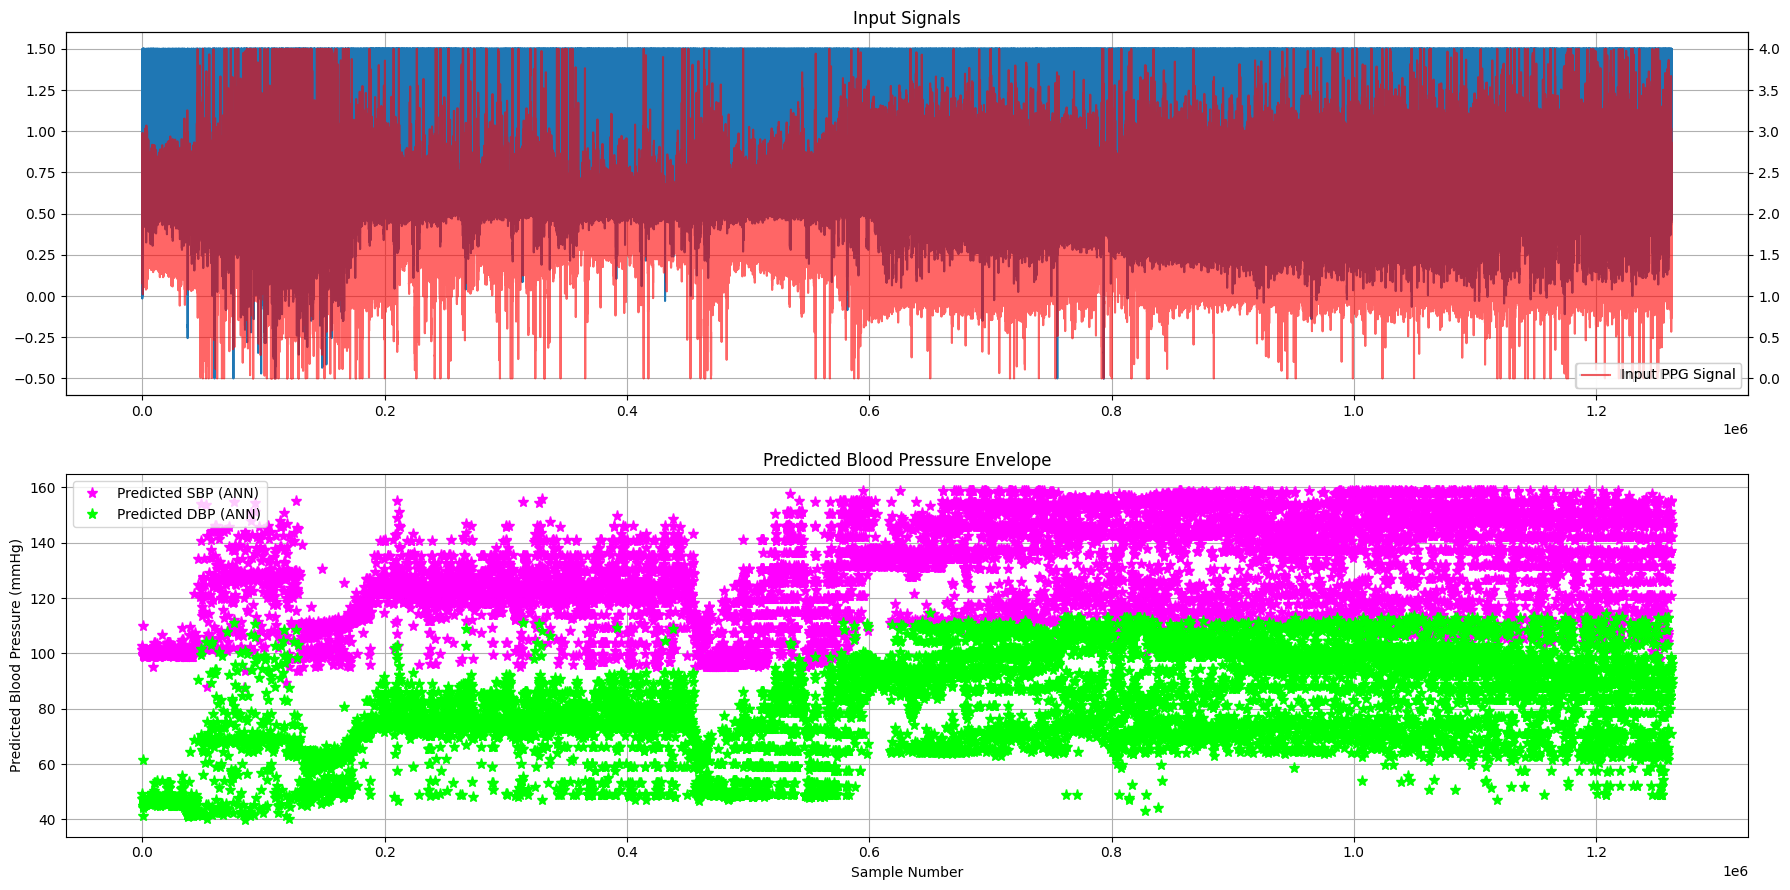

In [5]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import joblib

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs; low = lowcut / nyquist; high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band'); y = filtfilt(b, a, data)
    return y

def extract_features_from_new_file(base_file_name, folder_path):
    full_path = os.path.join(folder_path, base_file_name)
    print(f"--- Processing new file: {base_file_name} ---")
    try:
        record = wfdb.rdrecord(full_path); fs = record.fs
        ecg_index = record.sig_name.index('II'); ppg_index = record.sig_name.index('PLETH')
        ecg_signal_raw = record.p_signal[:, ecg_index]; ppg_signal_raw = record.p_signal[:, ppg_index]
        ecg_filtered = bandpass_filter(ecg_signal_raw, 0.5, 40.0, fs); ppg_filtered = bandpass_filter(ppg_signal_raw, 0.5, 4.0, fs)
        ecg_peaks, _ = find_peaks(ecg_filtered, height=np.mean(ecg_filtered), distance=int(0.5*fs))
        ppg_troughs, _ = find_peaks(-ppg_filtered, height=-np.mean(ppg_filtered), distance=int(0.5*fs))
        ptt_values_ms = []; hr_values = []; event_samples = []
        for i in range(1, len(ecg_peaks)):
            r_peak = ecg_peaks[i]; rr_interval_sec = (r_peak - ecg_peaks[i-1]) / fs; heart_rate = 60.0 / rr_interval_sec
            future_troughs = ppg_troughs[ppg_troughs > r_peak]
            if len(future_troughs) > 0 and 40 < heart_rate < 180:
                ptt_samples = future_troughs[0] - r_peak; ptt_ms = (ptt_samples / fs) * 1000
                if 50 < ptt_ms < 600:
                    ptt_values_ms.append(ptt_ms); hr_values.append(heart_rate); event_samples.append(r_peak)
        print(f"Feature extraction complete. Found {len(ptt_values_ms)} beats.")
        return ptt_values_ms, hr_values, event_samples, ecg_signal_raw, ppg_signal_raw, fs, record
    except Exception as e:
        print(f"Could not process file {base_file_name}. Error: {e}"); 
        return [], [], [], None, None, None, None

if __name__ == "__main__":
    print("Loading trained ANN models and parameters...")
    sbp_model = joblib.load('sbp_model_ann.joblib')
    dbp_model = joblib.load('dbp_model_ann.joblib')
    norm_params = joblib.load('norm_params_ann.joblib')
    print("Models loaded successfully.")

    folder_path = "D:/New folder (6)"
    new_file_name = "3042143_0013" 
    
    ptt_new, hr_new, samples_new, ecg_wave, ppg_wave, fs_new , record= extract_features_from_new_file(new_file_name, folder_path)

    if len(ptt_new) > 0:
        ptt_norm = (np.array(ptt_new) - norm_params['ptt_mean']) / norm_params['ptt_std']
        hr_norm = (np.array(hr_new) - norm_params['hr_mean']) / norm_params['hr_std']
        X_predict = np.column_stack((ptt_norm, hr_norm))
        
        sbp_predicted = sbp_model.predict(X_predict)
        dbp_predicted = dbp_model.predict(X_predict)
        
        plt.figure(figsize=(18, 9))
        ax1 = plt.subplot(2, 1, 1)
        ax1.plot(ecg_wave, label='Input ECG Signal'); ax1.set_title('Input Signals'); ax1.legend(); ax1.grid(True)
        ax2 = ax1.twinx()
        ax2.plot(ppg_wave, label='Input PPG Signal', color='red', alpha=0.6); ax2.legend(loc='lower right')
        
        ax3 = plt.subplot(2, 1, 2, sharex=ax1)
        ax3.plot(samples_new, sbp_predicted, '*', color='magenta', markersize=8, label='Predicted SBP (ANN)')
        ax3.plot(samples_new, dbp_predicted, '*', color='lime', markersize=8, label='Predicted DBP (ANN)')
        ax3.set_title('Predicted Blood Pressure Envelope'); ax3.set_xlabel('Sample Number'); ax3.set_ylabel('Predicted Blood Pressure (mmHg)'); ax3.legend(); ax3.grid(True)
        
        plt.tight_layout()
        plt.show()